In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as ml
from sklearn.model_selection import train_test_split

customer_csv = pd.read_csv("Telco-Customer-Churn.csv")

customer_csv.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
customer_csv.shape

(7043, 21)

In [ ]:
customer_csv.select_dtypes(include="number").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

NameError: name 'customer_csv' is not defined

In [8]:
customer_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
missing_value = customer_csv.isnull().sum()
missing_value[missing_value>0]

Series([], dtype: int64)

In [16]:
customer_csv.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


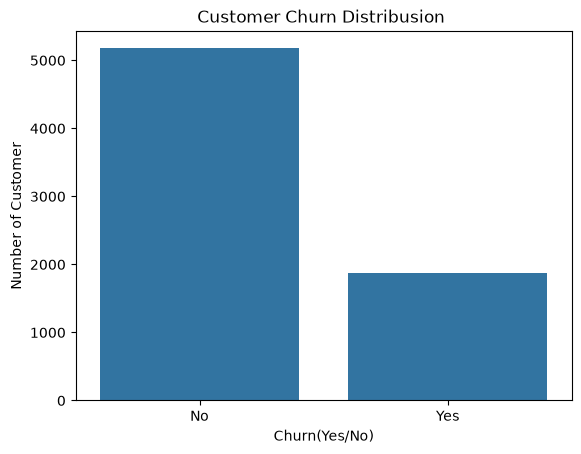

In [19]:
sns.countplot(x="Churn",data=customer_csv)
ml.title("Customer Churn Distribusion ")
ml.xlabel("Churn(Yes/No)")
ml.ylabel("Number of Customer")
ml.show()

In [43]:
((customer_csv["Churn"].value_counts()/len(customer_csv))*100).round(0)

Churn
No     73.0
Yes    27.0
Name: count, dtype: float64

Dari visualisasi di atas :

Pelanggan yang bertahan (No): $\approx 5.174$ pelanggan ($\approx 73\%$).

Pelanggan yang churn (Yes): $\approx 1.869$ pelanggan ($\approx 27\%$).

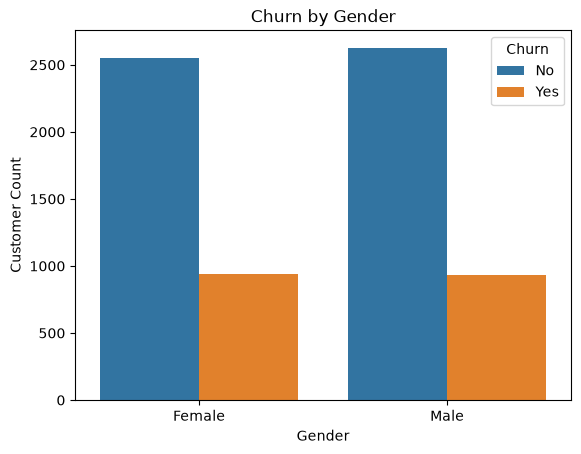

In [21]:
sns.countplot(x="gender", hue= "Churn", data=customer_csv)
ml.title("Churn by Gender")
ml.xlabel("Gender")
ml.ylabel("Customer Count")
ml.show()

Dari visualisasi di atas :

Jumlah total pria dan wanita hampir seimbang (masing-masing sekitar 2.500-an pelanggan).

Jumlah yang churn (Yes): Masing-masing sekitar 1000 pelanggan (pria maupun wanita).

Text(0.5, 1.0, 'Contract')

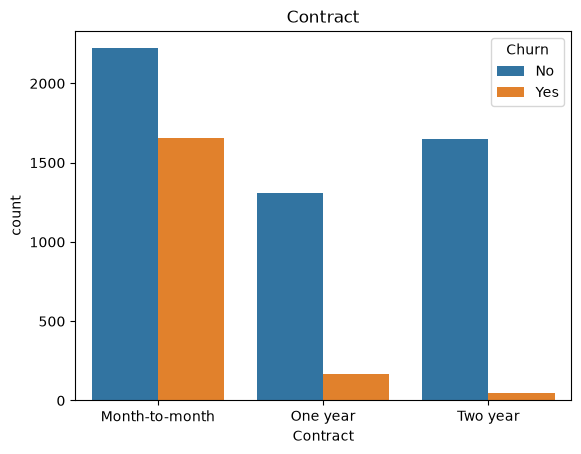

In [25]:
sns.countplot(x="Contract",data=customer_csv,hue="Churn")
ml.title("Contract")

Dari visualisasi Data di atas :

Month-to-month: Sekitar 3.800 pelanggan, dan hampir 1.650-an ($\approx 43\%$) di antaranya Churn.

One year: Sekitar 1.470 pelanggan, yang Churn hanya sekitar 166 

pelanggan.Two year: Sekitar 1.690 pelanggan, yang Churn hampir tidak ada (hanya sekitar 48 pelanggan).

Text(0.5, 1.0, 'Tenure Churn')

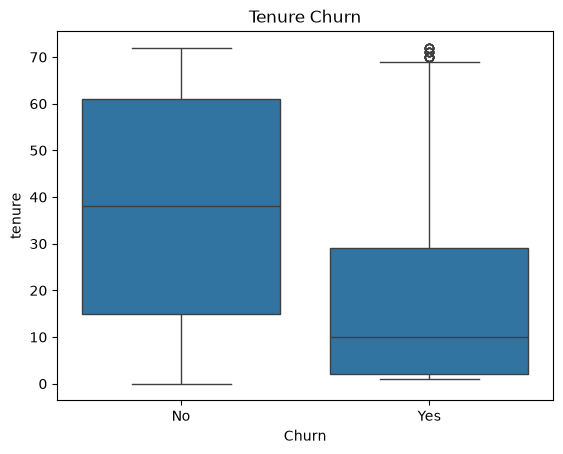

In [30]:
sns.boxplot(x="Churn",y="tenure", data=customer_csv)
ml.title("Tenure Churn")


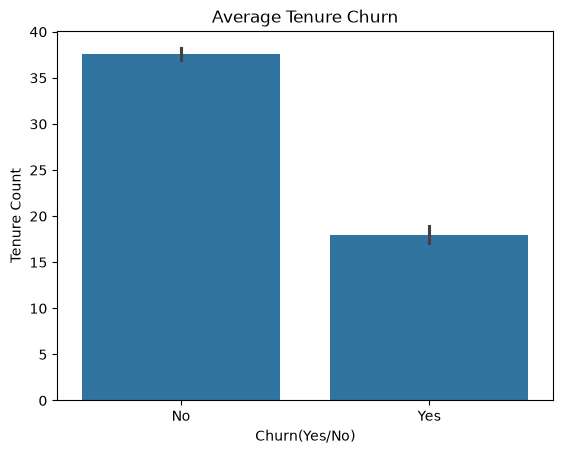

In [33]:
sns.barplot(x="Churn", y="tenure", estimator="mean",data=customer_csv)
ml.title("Average Tenure Churn")
ml.xlabel("Churn(Yes/No)")
ml.ylabel("Tenure Count")
ml.show()



In [11]:
output_file = "distinct_value.txt"

with open(output_file,"w",encoding="utf-8") as f :
    for colom in customer_csv.columns :
        f.write(f"Column :{colom}\n") 
        unique_vals= customer_csv[colom].unique().tolist()
        f.write(f"{unique_vals}\n\n")
        f.write("--"*50+"\n\n")
        
        
print(f"Distinct Value Has Been Save {output_file}")
        
        

Distinct Value Has Been Save distinct_value.txt


In [13]:
customer_csv.drop("customerID",axis=1, inplace=True)
customer_csv.drop("gender",axis=1, inplace=True)

KeyError: "['customerID'] not found in axis"

In [17]:
customer_csv["Partner"].value_counts()

def binary_encoding(colum) :
    if(colum.nunique() != 2):
        print("Unable to encoding")
        return colum
    maping = {"Yes":1, "No":0}
    return colum.map(maping).astype(int)

In [18]:
customer_csv["Partner"]= binary_encoding(customer_csv["Partner"])
customer_csv["Dependents"] = binary_encoding(customer_csv['Dependents'])
customer_csv["PhoneService"] = binary_encoding(customer_csv['PhoneService'])
customer_csv["Dependents"] = binary_encoding(customer_csv['Dependents'])
customer_csv["PaperlessBilling"] = binary_encoding(customer_csv['PaperlessBiling'])
customer_csv["Churn"] = binary_encoding(customer_csv['Churn'])



IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

In [16]:
customer_csv.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
colom_category = ["MultipleLines", "InternetService", "OnlineSecurity", 
    "OnlineBackup", "DeviceProtection", "TechSupport", 
    "StreamingTV", "StreamingMovies", "Contract", 
    "PaperlessBilling", "PaymentMethod"]

customer_csv = pd.get_dummies(data=customer_csv, columns=colom_category, drop_first=True)

In [20]:
customer_csv.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,29.85,29.85,No,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,0,0,34,1,56.95,1889.5,No,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,2,1,53.85,108.15,Yes,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0,0,45,0,42.30,1840.75,No,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,0,0,2,1,70.70,151.65,Yes,False,False,...,False,False,False,False,False,False,True,False,True,False


In [24]:
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_row', None)

customer_csv = customer_csv[pd.to_numeric(customer_csv['TotalCharges'],errors='coerce').notnull()]
customer_csv['TotalCharges']= pd.to_numeric(customer_csv['TotalCharges'],errors='coerce')


In [25]:
customer_csv.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   MonthlyCharges                         7032 non-null   float64
 6   TotalCharges                           7032 non-null   float64
 7   Churn                                  7032 non-null   str    
 8   MultipleLines_No phone service         7032 non-null   bool   
 9   MultipleLines_Yes                      7032 non-null   bool   
 10  InternetService_Fiber optic            7032 non-null   bool   
 11  InternetService_No  

In [27]:
X = customer_csv.drop(columns='Churn')
y = customer_csv['Churn']

In [31]:
train_X,val_X,train_y,val_y = train_test_split(X,y,test_size=0.2,stratify=y ,random_state=42)

print(y.value_counts(normalize=True))
print(val_y.value_counts(normalize=True))
print(train_y.value_counts(normalize=True))

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64
Churn
No     0.734186
Yes    0.265814
Name: proportion, dtype: float64
Churn
No     0.734222
Yes    0.265778
Name: proportion, dtype: float64


Accuracy 0.7974413646055437
Classification               precision    recall  f1-score   support

          No       0.85      0.88      0.86      1033
         Yes       0.63      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



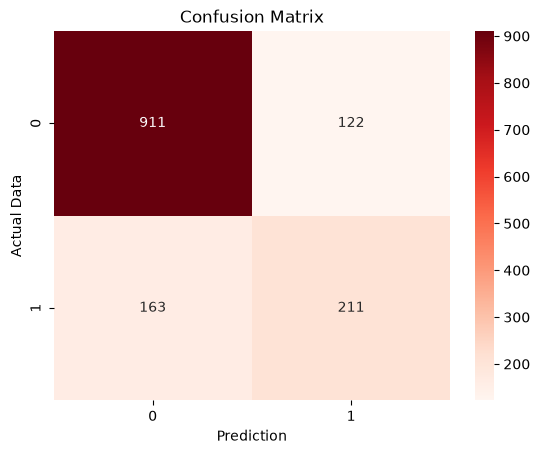

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,roc_auc_score,roc_curve

model = LogisticRegression(max_iter=1000, solver='liblinear')

model.fit(train_X,train_y)

prediction_LR = model.predict(val_X)

prediction_proba= model.predict_proba(val_X)[:,1]

print("Accuracy", accuracy_score(val_y,prediction_LR))

print("Classification", classification_report(val_y,prediction_LR))

conf_matrix=confusion_matrix(val_y,prediction_LR)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Reds')
ml.title("Confusion Matrix")
ml.ylabel("Actual Data")
ml.xlabel("Prediction")
ml.show()

Actual data 1 dan prediksinya 1 -> 211

Actual data 0 dan prediksinya 0 -> 911

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(n_estimators=200,max_depth=8,min_samples_split=5,min_samples_leaf=2,class_weight='balanced',random_state=42)

model_2.fit(train_X,train_y)

prediction_RF= model_2.predict(val_X)

prediction_proba_RF = model_2.predict_proba(val_X)

print(confusion_matrix(val_y,prediction_RF))

print(classification_report(val_y,prediction_RF))




[[742 291]
 [ 74 300]]
              precision    recall  f1-score   support

          No       0.91      0.72      0.80      1033
         Yes       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407

